In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [9]:
sns.set_theme(style="whitegrid") # Estilo limpio y académico
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# Nombres de tus archivos (Asegúrate de que coinciden con los que tienes en la carpeta)
archivo_cobertura = '20260608_130056_metricas_MatrizCobertura.csv'
archivo_ganancia = '20260608_130056_metricas_GananciaInformacion.csv'
archivo_tasa = '20260608_130056_metricas_TasaExploracion.csv'
archivo_completitud = '20260608_130056_metricas_TiempoCompletitud.csv'

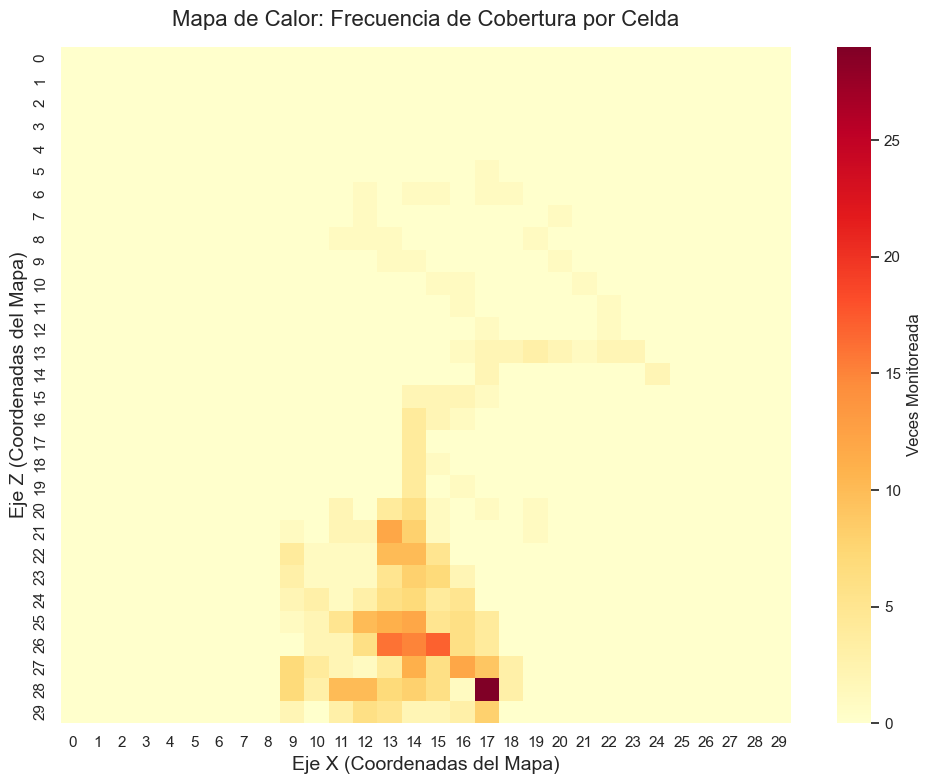

In [10]:
# ==========================================
# 1. HEATMAP: MATRIZ DE COBERTURA
# ==========================================
if os.path.exists(archivo_cobertura):
    # Leemos sin cabeceras porque es una matriz pura
    df_cobertura = pd.read_csv(archivo_cobertura, header=None)
    
    plt.figure(figsize=(10, 8))
    # cmap='YlOrRd' usa colores de Amarillo a Rojo (perfecto para mapas de calor/fuego)
    sns.heatmap(df_cobertura, cmap='YlOrRd', cbar_kws={'label': 'Veces Monitoreada'})
    plt.title('Mapa de Calor: Frecuencia de Cobertura por Celda', fontsize=16, pad=15)
    plt.xlabel('Eje X (Coordenadas del Mapa)', fontsize=14)
    plt.ylabel('Eje Z (Coordenadas del Mapa)', fontsize=14)
    plt.tight_layout()
    plt.savefig('TFG_Heatmap_Cobertura.png', dpi=300) # dpi=300 es calidad de impresión TFG
    plt.show()

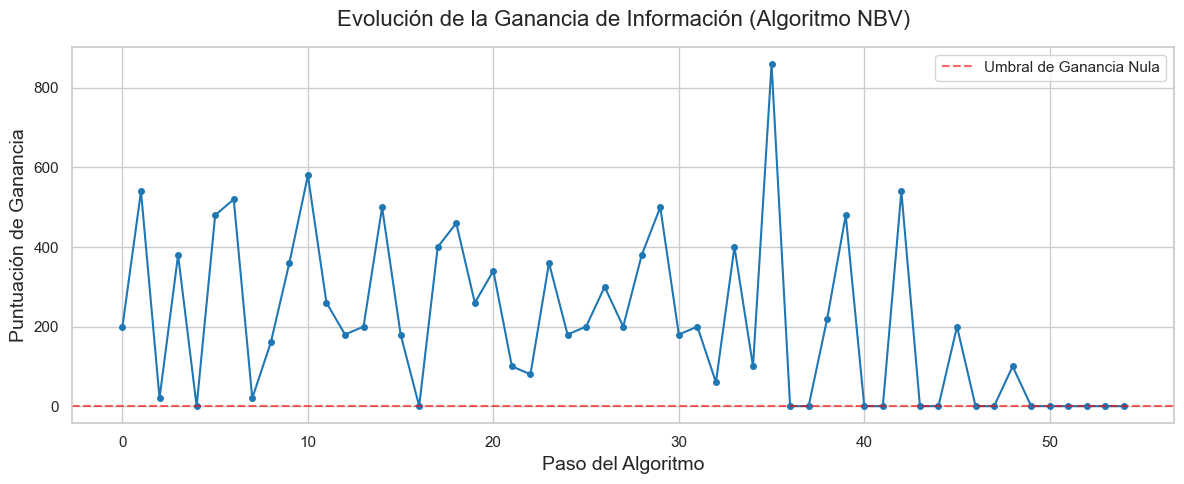

In [11]:
# ==========================================
# 2. GRÁFICO DE LÍNEAS: GANANCIA DE INFORMACIÓN
# ==========================================
if os.path.exists(archivo_ganancia):
    df_ganancia = pd.read_csv(archivo_ganancia)
    
    plt.figure(figsize=(12, 5))
    plt.plot(df_ganancia['PasoAlgoritmo'], df_ganancia['Ganancia'], 
             marker='o', linestyle='-', color='#1f77b4', markersize=4)
    
    # Añadimos una línea horizontal roja en el 0 para marcar el umbral de "Fallo"
    plt.axhline(0, color='red', linestyle='--', alpha=0.6, label='Umbral de Ganancia Nula')
    
    plt.title('Evolución de la Ganancia de Información (Algoritmo NBV)', fontsize=16, pad=15)
    plt.xlabel('Paso del Algoritmo', fontsize=14)
    plt.ylabel('Puntuación de Ganancia', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.savefig('TFG_Ganancia_Info.png', dpi=300)
    plt.show()

C:\Users\fran2\AppData\Local\Temp\ipykernel_8600\556209255.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DroneID', y='Tasa', data=df_tasa_limpio, palette='Set2')


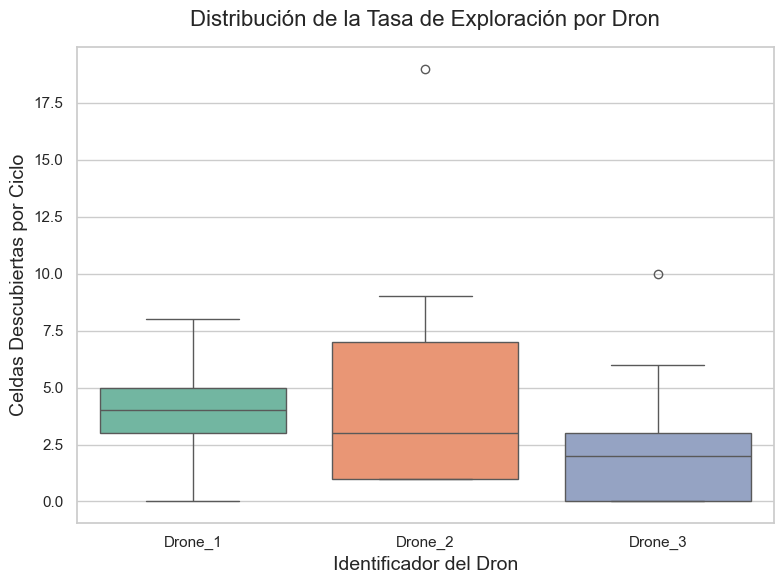

In [12]:
# ==========================================
# 3. BOXPLOT: TASA DE EXPLORACIÓN POR DRON
# ==========================================
if os.path.exists(archivo_tasa):
    df_tasa = pd.read_csv(archivo_tasa)
    
    # ¡LIMPIEZA DE DATOS! Filtramos al dron principal/buggeado
    df_tasa_limpio = df_tasa[df_tasa['DroneID'] != 'ppalDrone']
    
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='DroneID', y='Tasa', data=df_tasa_limpio, palette='Set2')
    
    plt.title('Distribución de la Tasa de Exploración por Dron', fontsize=16, pad=15)
    plt.xlabel('Identificador del Dron', fontsize=14)
    plt.ylabel('Celdas Descubiertas por Ciclo', fontsize=14)
    plt.tight_layout()
    plt.savefig('TFG_Boxplot_Exploracion.png', dpi=300)
    plt.show()

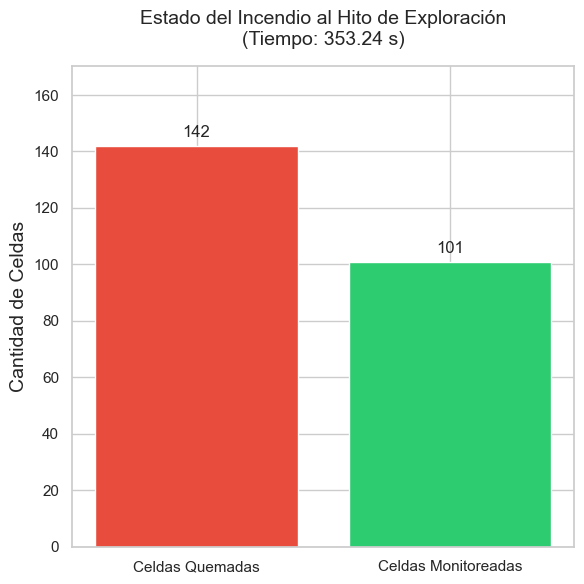

In [13]:
# ==========================================
# 4. GRÁFICO DE BARRAS: TIEMPO DE COMPLETITUD (HITO)
# ==========================================
if os.path.exists(archivo_completitud):
    # ¡AQUÍ ESTÁ LA MAGIA! Añadimos decimal=',' para que entienda el formato europeo
    df_completitud = pd.read_csv(archivo_completitud, sep=';', decimal=',')
    
    # Extraemos los valores de la primera y única fila
    quemadas = df_completitud['CeldasQuemadas'].iloc[0]
    monitoreadas = df_completitud['CeldasMonitoreadas'].iloc[0]
    tiempo = df_completitud['TiempoTranscurrido'].iloc[0]
    
    plt.figure(figsize=(6, 6))
    bars = plt.bar(['Celdas Quemadas', 'Celdas Monitoreadas'], [quemadas, monitoreadas], color=['#e74c3c', '#2ecc71'])
    
    # Añadimos el número exacto encima de cada barra
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, int(yval), ha='center', va='bottom', fontsize=12)
        
    plt.title(f'Estado del Incendio al Hito de Exploración\n(Tiempo: {tiempo:.2f} s)', fontsize=14, pad=15)
    plt.ylabel('Cantidad de Celdas', fontsize=14)
    plt.ylim(0, max(quemadas, monitoreadas) * 1.2) # Damos espacio extra arriba
    plt.tight_layout()
    plt.savefig('TFG_Completitud_Barras.png', dpi=300)
    plt.show()